# 1. Análisis del Impacto de Noticias y Opiniones en la Volatilidad de Memecoins mediante NLP

A continuación en este notebook se realizará un EDA de los diferentes ficheros a emplear durante el proyecto, también se analizará los sentimientos de uno de los datasets recogidos y por último se analizarán la relación entre las diferentes opiniones con la volatilidad de los memecoins.

In [3]:
#imports e instalación de librerias
#!pip install --upgrade numpy scikit-learn pandas matplotlib tensorflow
import os
import json
import pandas as pd
from pandas.tseries.offsets import BDay
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pymongo import MongoClient
from datetime import datetime
from nltk import download as nltk_download
from nltk.sentiment import SentimentIntensityAnalyzer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler


In [4]:
#Accesos a colleciones de MongoDB
# Conectarse al cluster de MongoDB Atlas
# Detectar colección más reciente por prefijo
# Función genérica para obtener la colección más reciente por prefijo
def get_latest_collection_by_prefix(prefix: str):
    collections = db.list_collection_names()
    filtered = sorted([name for name in collections if name.startswith(prefix)], reverse=True)
    if not filtered:
        raise ValueError(f"No se encontró ninguna colección que comience con '{prefix}'")
    return db[filtered[0]], filtered[0]


# Leer las credenciales desde el archivo JSON
with open('config.json', 'r') as f:
    config = json.load(f)

uri = config["mongo_uri"]

# Conectar a MongoDB
client = MongoClient(uri)
db = client["crypto_analysis"]

# Acceder a las colecciones más recientes
collection_volatility, vol_name = get_latest_collection_by_prefix("memecoins_volatility_data_")
collection_prices, price_name = get_latest_collection_by_prefix("memecoins_prices_data_")
collection_reddit, reddit_news = get_latest_collection_by_prefix("memecoins_reddit_raw_")

# 2. EDA de Datos de Criptomonedas
 En este punto realizaremos un Análisis Exploratorio de Datos (EDA) utilizando dos conjuntos de datos relacionados con la volatilidad de criptomonedas.

 El primer conjunto contiene información sobre PEPE, DOGE y SHIBA durante 365 días, y el segundo conjunto sobre el precio diario en 365 días será analizado de manera similar.

 Utilizaremos bibliotecas como ggplot2, dplyr y otros para explorar y visualizar las métricas relacionadas con el rango de precios, cambio
 porcentual y volatilidad relativa.


## 2.1 EDA sobre memecoins_volatility_data

In [5]:

# Leer los datos y convertirlos en DataFrames
data_volatility = list(collection_volatility.find())

df_vol = pd.DataFrame(data_volatility)

# Verificar los nombres usados
print(f" Estructura de la Colección de volatilidad usada: {vol_name}")

# Verificar las primeras filas
print(df_vol.head())

 Estructura de la Colección de volatilidad usada: memecoins_volatility_data_05_06_2025
                        _id       date      open      high       low  \
0  6841474867ab49933a560829 2024-06-22  0.000011  0.000012  0.000010   
1  6841474867ab49933a56082a 2024-06-26  0.000011  0.000013  0.000010   
2  6841474867ab49933a56082c 2024-07-04  0.000011  0.000012  0.000010   
3  6841474867ab49933a560837 2024-08-17  0.000008  0.000008  0.000007   
4  6841474867ab49933a560858 2024-12-27  0.000018  0.000019  0.000017   

      close     range  pct_change  rel_volatility  coin  
0  0.000011  0.000002    2.148612        0.186067  pepe  
1  0.000013  0.000003   11.975524        0.232918  pepe  
2  0.000010  0.000002   -9.380531        0.186907  pepe  
3  0.000007  0.000002  -12.879708        0.195567  pepe  
4  0.000017  0.000002   -2.579921        0.125376  pepe  


In [6]:
# Asegurarse de que la columna 'date' esté en formato datetime
df_vol['date'] = pd.to_datetime(df_vol['date'])

# Verificar los tipos de datos (opcional)
print(df_vol.dtypes)

# Obtener la lista de monedas únicas
coins = df_vol['coin'].unique()

# Generar resumen estadístico por cada coin
for coin in coins:
    print(f"\nResumen estadístico para {coin}:")
    print(df_vol[df_vol['coin'] == coin].describe())

# Convertir columna 'date' a datetime
df_vol['date'] = pd.to_datetime(df_vol['date'])

# Lista de columnas numéricas
numeric_cols = ['open', 'high', 'low', 'close', 'range', 'pct_change', 'rel_volatility']

# Reemplazar ',' por '.' SOLO si es string, luego convertir a float
for col in numeric_cols:
    if df_vol[col].dtype == 'object':
        df_vol[col] = df_vol[col].str.replace(',', '.')
        df_vol[col] = pd.to_numeric(df_vol[col], errors='coerce')

# Confirmar tipos de datos
print(df_vol.dtypes)

# Ver resumen correcto para PEPE
print("\nResumen estadístico para PEPE:")
print(df_vol[df_vol['coin'] == 'pepe'][numeric_cols].describe())

_id                       object
date              datetime64[ns]
open                     float64
high                     float64
low                      float64
close                    float64
range                    float64
pct_change               float64
rel_volatility           float64
coin                      object
dtype: object

Resumen estadístico para pepe:
                      date       open       high        low      close  \
count                   92  92.000000  92.000000  92.000000  92.000000   
mean   2024-12-05 00:00:00   0.000012   0.000013   0.000010   0.000012   
min    2024-06-06 00:00:00   0.000007   0.000007   0.000005   0.000007   
25%    2024-09-05 00:00:00   0.000008   0.000009   0.000008   0.000008   
50%    2024-12-05 00:00:00   0.000010   0.000011   0.000009   0.000010   
75%    2025-03-06 00:00:00   0.000014   0.000015   0.000012   0.000014   
max    2025-06-05 00:00:00   0.000024   0.000028   0.000022   0.000024   
std                    NaN   0.0

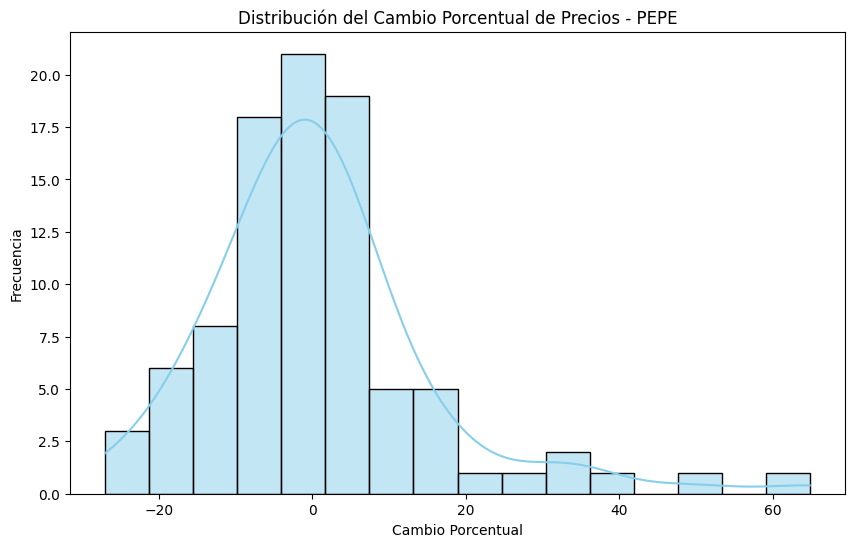

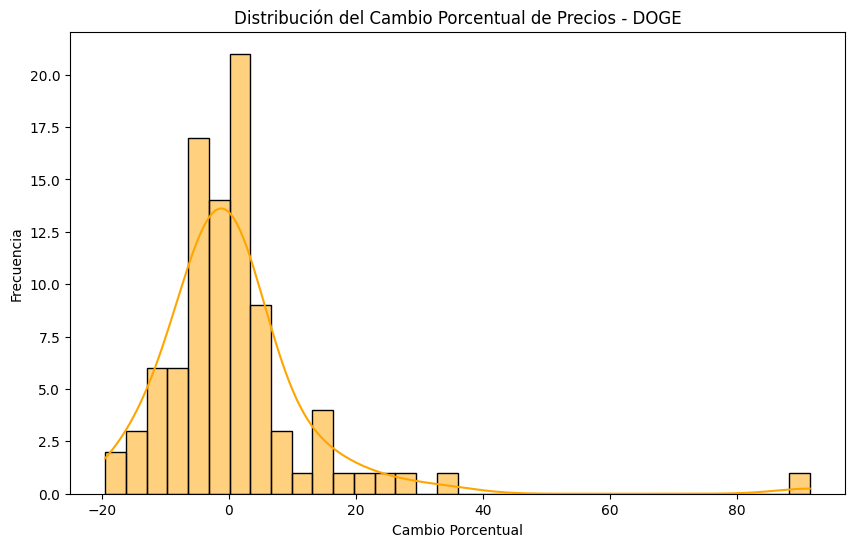

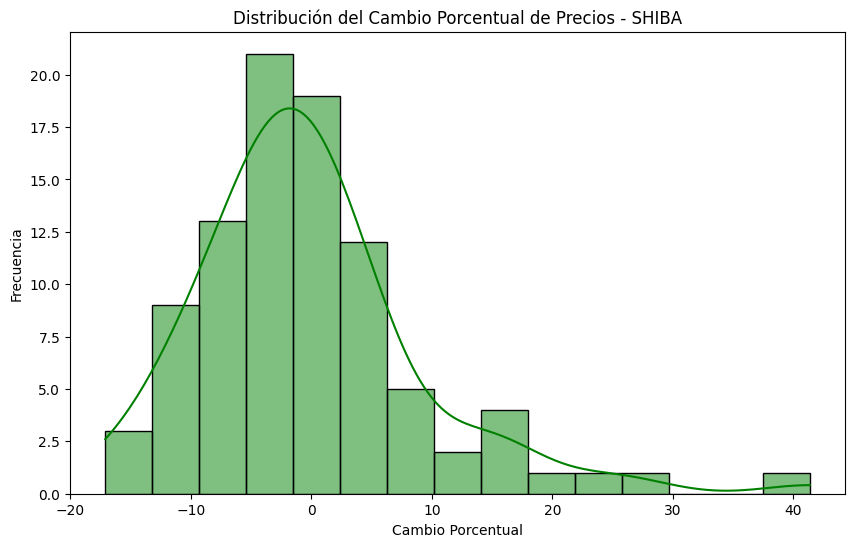

In [7]:
# Filtrar los datos para cada criptomoneda y crear los histogramas para cada una

# Histograma para PEPE
plt.figure(figsize=(10, 6))
sns.histplot(df_vol[df_vol['coin'] == 'pepe']['pct_change'], kde=True, color='skyblue')
plt.title('Distribución del Cambio Porcentual de Precios - PEPE')
plt.xlabel('Cambio Porcentual')
plt.ylabel('Frecuencia')
plt.show()

# Histograma para DOGE
plt.figure(figsize=(10, 6))
sns.histplot(df_vol[df_vol['coin'] == 'doge']['pct_change'], kde=True, color='orange')
plt.title('Distribución del Cambio Porcentual de Precios - DOGE')
plt.xlabel('Cambio Porcentual')
plt.ylabel('Frecuencia')
plt.show()

# Histograma para SHIBA
plt.figure(figsize=(10, 6))
sns.histplot(df_vol[df_vol['coin'] == 'shiba']['pct_change'], kde=True, color='green')
plt.title('Distribución del Cambio Porcentual de Precios - SHIBA')
plt.xlabel('Cambio Porcentual')
plt.ylabel('Frecuencia')
plt.show()

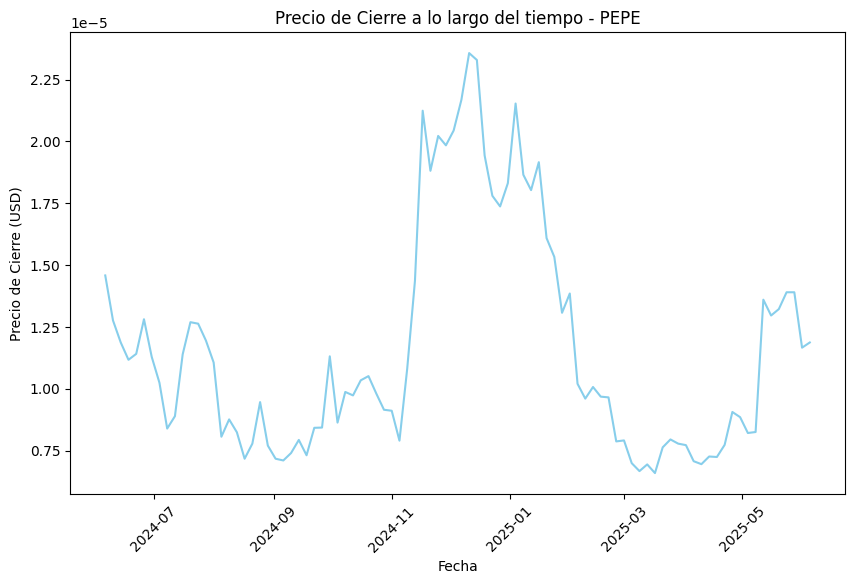

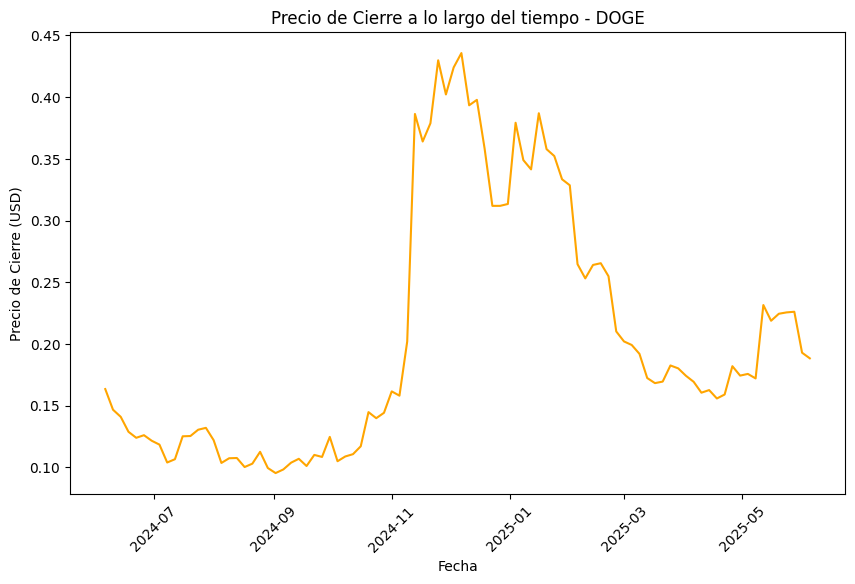

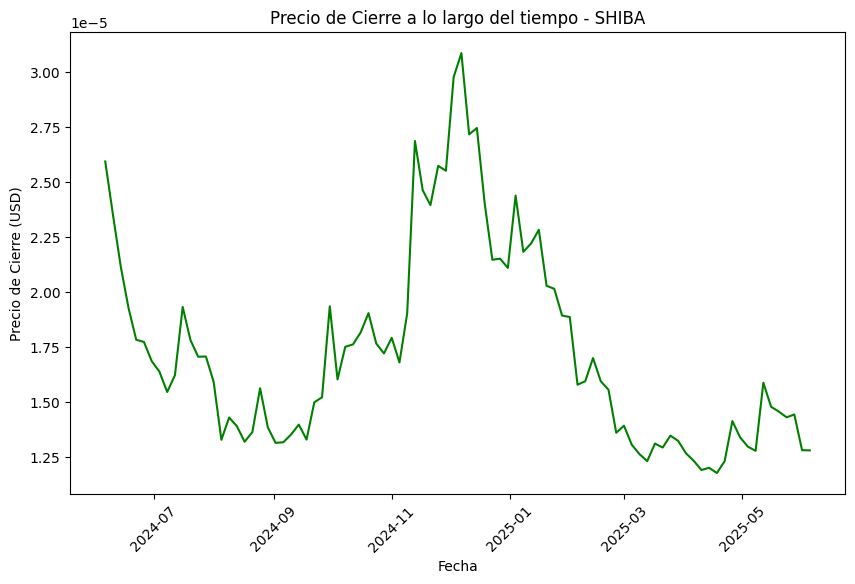

In [8]:
# Gráfico de serie temporal para PEPE
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='close', data=df_vol[df_vol['coin'] == 'pepe'], color='skyblue')
plt.title('Precio de Cierre a lo largo del tiempo - PEPE')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

# Gráfico de serie temporal para DOGE
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='close', data=df_vol[df_vol['coin'] == 'doge'], color='orange')
plt.title('Precio de Cierre a lo largo del tiempo - DOGE')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

# Gráfico de serie temporal para SHIBA
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='close', data=df_vol[df_vol['coin'] == 'shiba'], color='green')
plt.title('Precio de Cierre a lo largo del tiempo - SHIBA')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()


## 2.2 EDA sobre memecoins_prices_data

In [9]:
# Leer los datos y convertirlos en DataFrames
data_prices = list(collection_prices.find())

df_prices = pd.DataFrame(data_prices)

# Verificar los nombres usados
print(f" Estructura de la Colección de precios usada: {price_name}")

# Verificar las primeras filas
print(df_prices.head())

 Estructura de la Colección de precios usada: memecoins_prices_data_05_06_25
                        _id       date  coin     price        volume  \
0  684145304a860b1d4f3f0222 2024-06-21  pepe  0.000011  8.090444e+08   
1  684145304a860b1d4f3f023d 2024-07-18  pepe  0.000012  1.487600e+09   
2  684145304a860b1d4f3f0255 2024-08-11  pepe  0.000008  5.691814e+08   
3  684145304a860b1d4f3f0257 2024-08-13  pepe  0.000008  1.169279e+09   
4  684145304a860b1d4f3f0269 2024-08-31  pepe  0.000008  1.039300e+09   

     market_cap  
0  4.618936e+09  
1  4.922633e+09  
2  3.546677e+09  
3  3.472503e+09  
4  3.273542e+09  


In [10]:
# Conversión de tipos de datos
df_prices['date'] = pd.to_datetime(df_prices['date'])
df_prices['price'] = df_prices['price'].astype(float)

# Redondear los precios
df_prices['price_rounded_no_exp'] = df_prices['price'].apply(lambda x: round(x, 8))

# Verificar los tipos de datos después de la conversión
print(df_prices.dtypes)

# Obtener lista de monedas
coins = df_prices['coin'].unique()

# Resumen estadístico por moneda
for coin in coins:
    print(f"\nResumen estadístico de precios para {coin}:")
    print(df_prices[df_prices['coin'] == coin].describe())


_id                             object
date                    datetime64[ns]
coin                            object
price                          float64
volume                         float64
market_cap                     float64
price_rounded_no_exp           float64
dtype: object

Resumen estadístico de precios para pepe:
                                date       price        volume    market_cap  \
count                            372  372.000000  3.720000e+02  3.720000e+02   
mean   2024-12-08 10:11:36.774193664    0.000012  1.712367e+09  4.910378e+09   
min              2024-06-06 00:00:00    0.000006  3.020866e+08  2.429367e+09   
25%              2024-09-06 18:00:00    0.000008  7.627871e+08  3.399605e+09   
50%              2024-12-08 12:00:00    0.000010  1.081860e+09  4.243513e+09   
75%              2025-03-11 06:00:00    0.000013  1.770576e+09  5.653294e+09   
max              2025-06-05 00:00:00    0.000026  1.918689e+10  1.110002e+10   
std                           

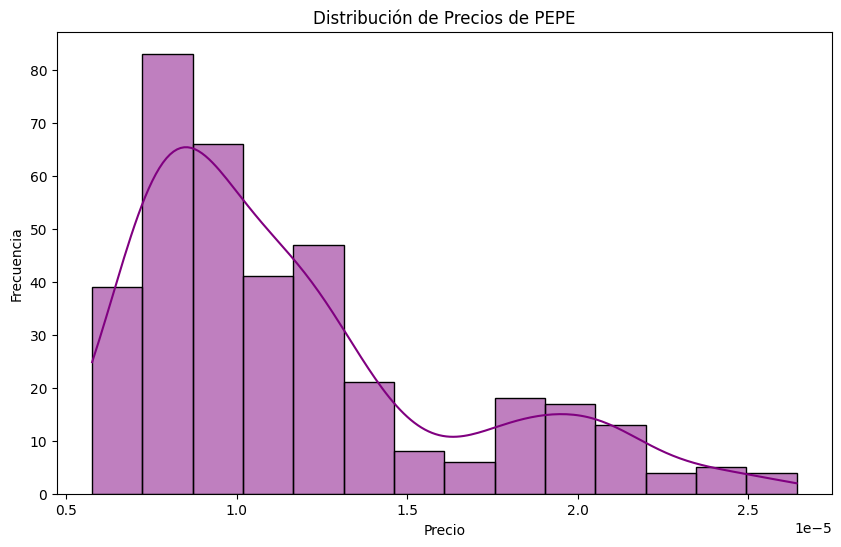

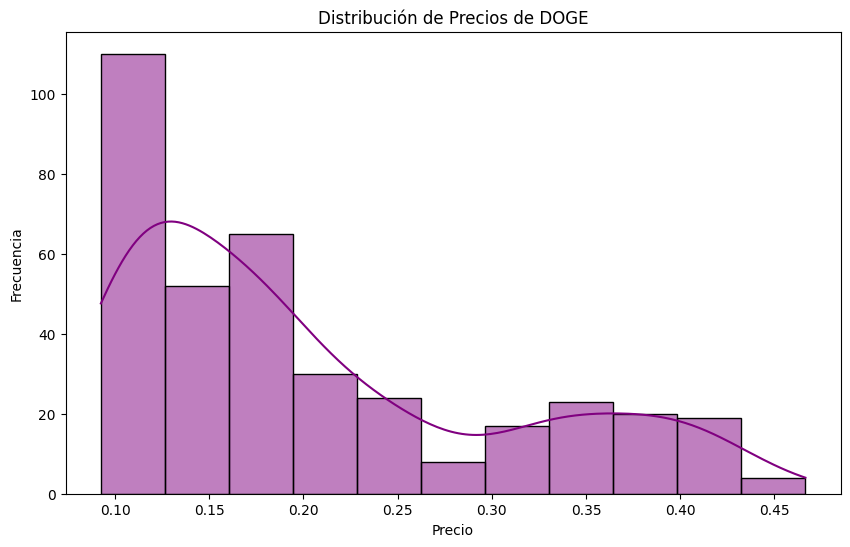

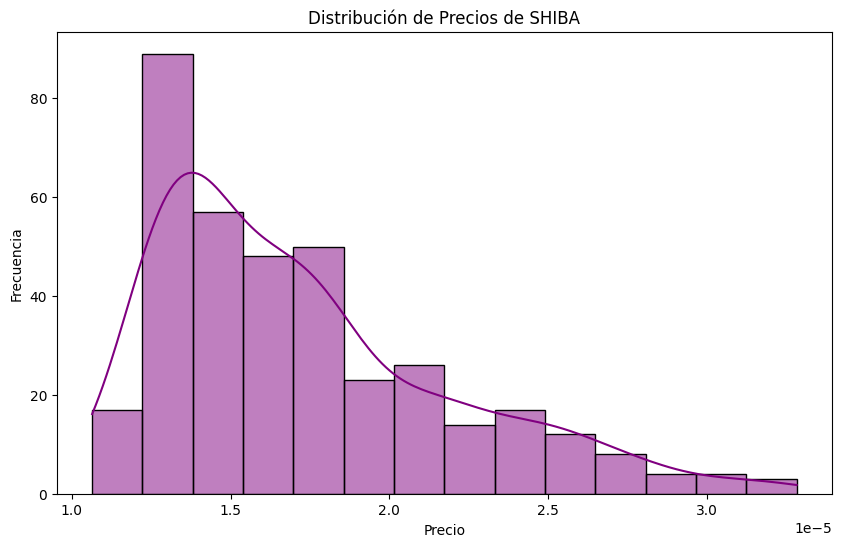

In [11]:
# Histograma de precios para cada criptomoneda
for coin in df_prices['coin'].unique():
    plt.figure(figsize=(10, 6))
    sns.histplot(df_prices[df_prices['coin'] == coin]['price_rounded_no_exp'], kde=True, color='purple')
    plt.title(f'Distribución de Precios de {coin.upper()}')
    plt.xlabel('Precio')
    plt.ylabel('Frecuencia')
    plt.show()


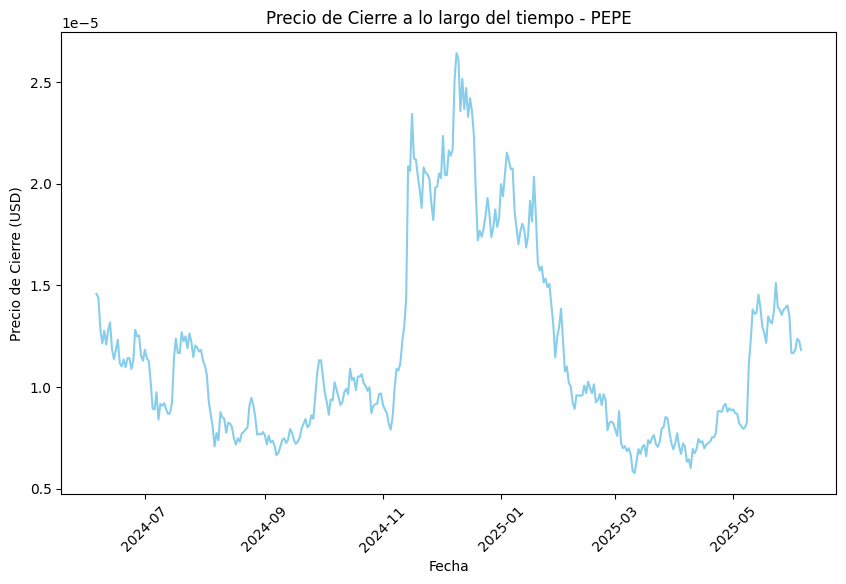

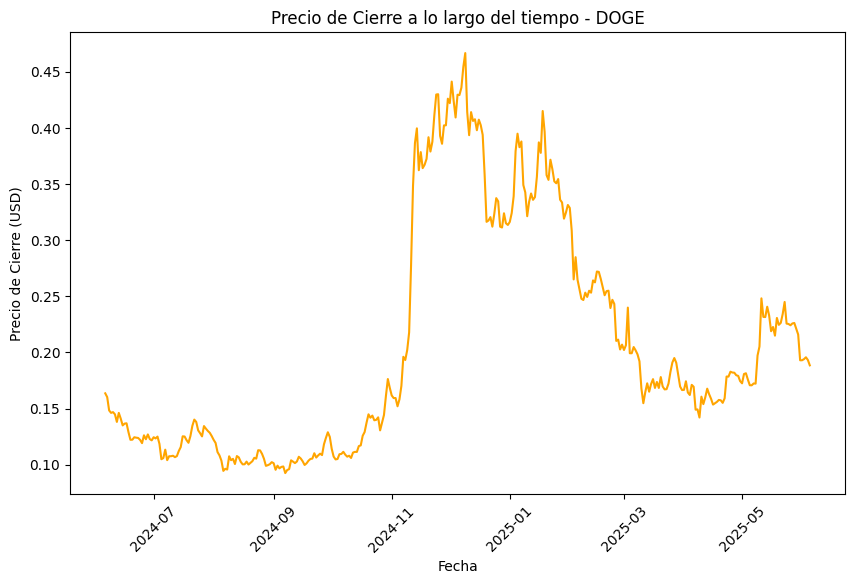

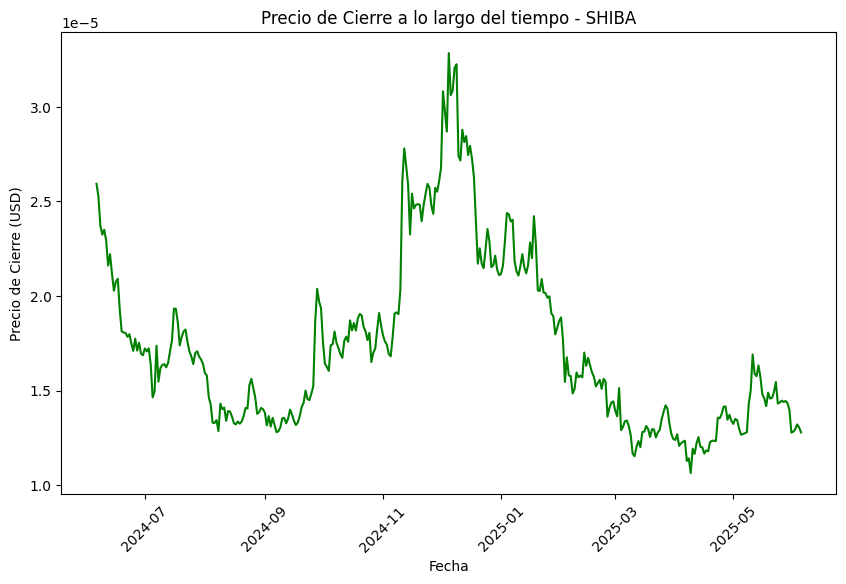

In [12]:
# Gráfico de serie temporal para PEPE
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='price_rounded_no_exp', data=df_prices[df_prices['coin'] == 'pepe'], color='skyblue')
plt.title('Precio de Cierre a lo largo del tiempo - PEPE')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

# Gráfico de serie temporal para DOGE
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='price_rounded_no_exp', data=df_prices[df_prices['coin'] == 'doge'], color='orange')
plt.title('Precio de Cierre a lo largo del tiempo - DOGE')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

# Gráfico de serie temporal para SHIBA
plt.figure(figsize=(10, 6))
sns.lineplot(x='date', y='price_rounded_no_exp', data=df_prices[df_prices['coin'] == 'shiba'], color='green')
plt.title('Precio de Cierre a lo largo del tiempo - SHIBA')
plt.xlabel('Fecha')
plt.ylabel('Precio de Cierre (USD)')
plt.xticks(rotation=45)
plt.show()

## 2.3 EDA sobre news_data


In [13]:
# Leer los datos y convertirlos en DataFrames
data_news = list(collection_reddit.find())

df_news = pd.DataFrame(data_news)

# Verificar los nombres usados
print(f" Estructura de la Colección de precios usada: {price_name}")
# Verificar los tipos de datos después de la conversión
print(df_news.dtypes)

# Obtener lista de sources
sources = df_news['subreddit'].unique()
print(f" Lista de subrredits empleados: {sources}")

 Estructura de la Colección de precios usada: memecoins_prices_data_05_06_25
_id                  object
date         datetime64[ns]
title                object
selftext             object
url                  object
subreddit            object
coin                 object
filter               object
dtype: object
 Lista de subrredits empleados: ['CryptoCurrency' 'altcoin' 'dogecoin' 'worldnews' 'Economics' 'Bitcoin'
 'ethereum' 'SHIBArmy' 'shiba' 'pepecoin' 'PEPEthefrog' 'cryptomoonshots']


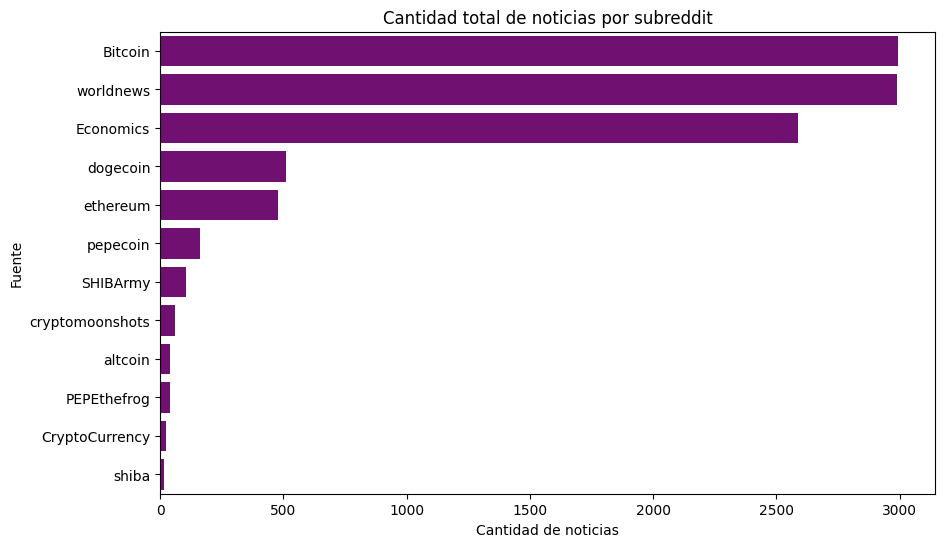

In [23]:
# Gráfico de barras de cantidad total de noticias por fuente (subrredit)
plt.figure(figsize=(10,6))
sns.countplot(data=df_news, y='subreddit', color='purple', order=df_news['subreddit'].value_counts().index)
plt.title('Cantidad total de noticias por subreddit')
plt.xlabel('Cantidad de noticias')
plt.ylabel('Fuente')
plt.show()

# 3. Análisis de sentimientos
En este punto realizamos el análisis de los textos recogidos de Reddit y sus diferentes subreddits sobre noticias financieras utilizando tres algoritmos distintos de análisis de sentimiento, con el objetivo de comparar su precisión y consistencia en contextos relacionados con mercados volátiles y memecoins:

VADER (Valence Aware Dictionary and sEntiment Reasoner): Un modelo basado en reglas y diccionario, optimizado para textos sociales en inglés. Su índice compound se transforma a una escala de 0 a 1 para su comparación.

ChatGPT a través de la API de OpenAI: Un enfoque más contextual y flexible basado en modelos de lenguaje avanzados, que devuelve una puntuación de sentimiento entre 0 y 1 interpretando directamente cada titular.


## 3.2 VADER

In [15]:
# Inicializar VADER
try:
    sia = SentimentIntensityAnalyzer()
except:
    nltk_download("vader_lexicon")
    sia = SentimentIntensityAnalyzer()

In [16]:
# Aplicar VADER
df_news["text"] = df_news["title"].fillna('') + " " + df_news["selftext"].fillna('')
df_news["score"] = df_news["text"].apply(lambda x: sia.polarity_scores(x)["compound"])

# Guardar colección con sentimiento
today_str = datetime.today().strftime("%d_%m_%y")
collection_sentiment = db[f"memecoins_reddit_sentiment_{today_str}"]
# Eliminar la colección existente si ya existe
if collection_sentiment.name in db.list_collection_names():
    db.drop_collection(collection_sentiment.name)
collection_sentiment.insert_many(df_news.drop(columns=["text"]).to_dict("records"))
print(f"Sentimientos guardados en: memecoins_reddit_sentiment_{today_str}")

Sentimientos guardados en: memecoins_reddit_sentiment_06_06_25


### 3.2.1 EDA news_data_sentimental_analysis_mean_VADER


Resumen por moneda:
   coin  count      mean       std     min     max
0  DOGE   3550  0.047824  0.439425 -0.9996  0.9995
1  PEPE   3307  0.061733  0.465425 -0.9996  0.9995
2  SHIB   3153  0.048370  0.464324 -0.9996  0.9992


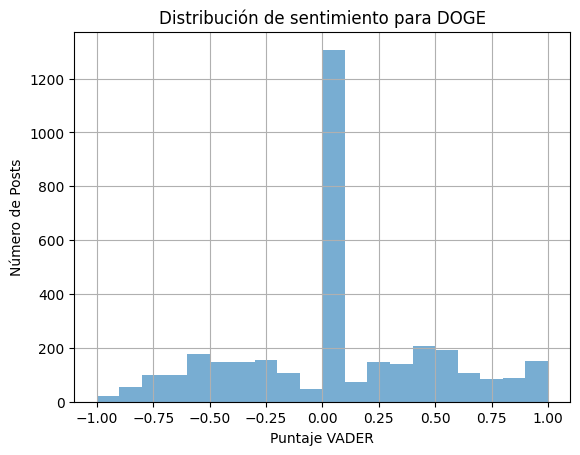

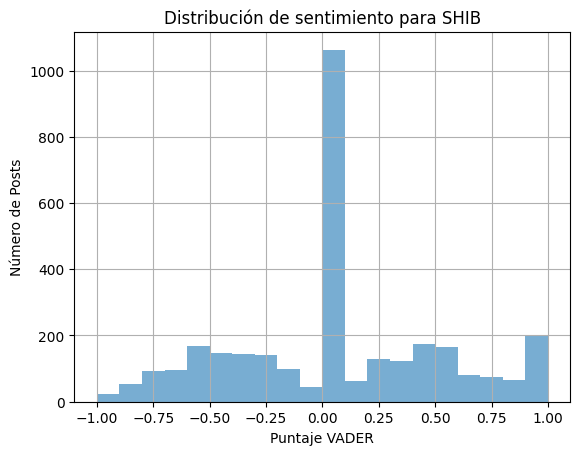

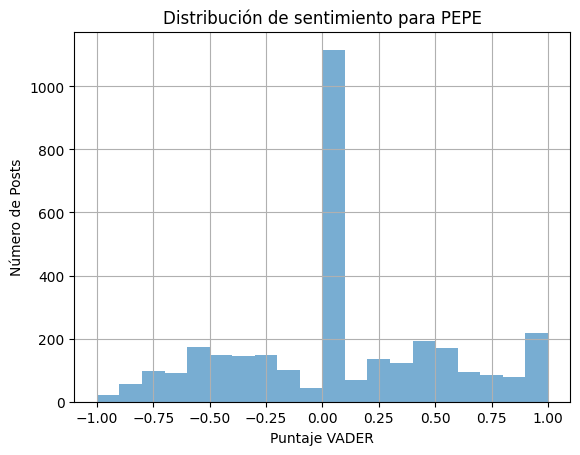

Evolución temporal del sentimiento (promedio diario por moneda):


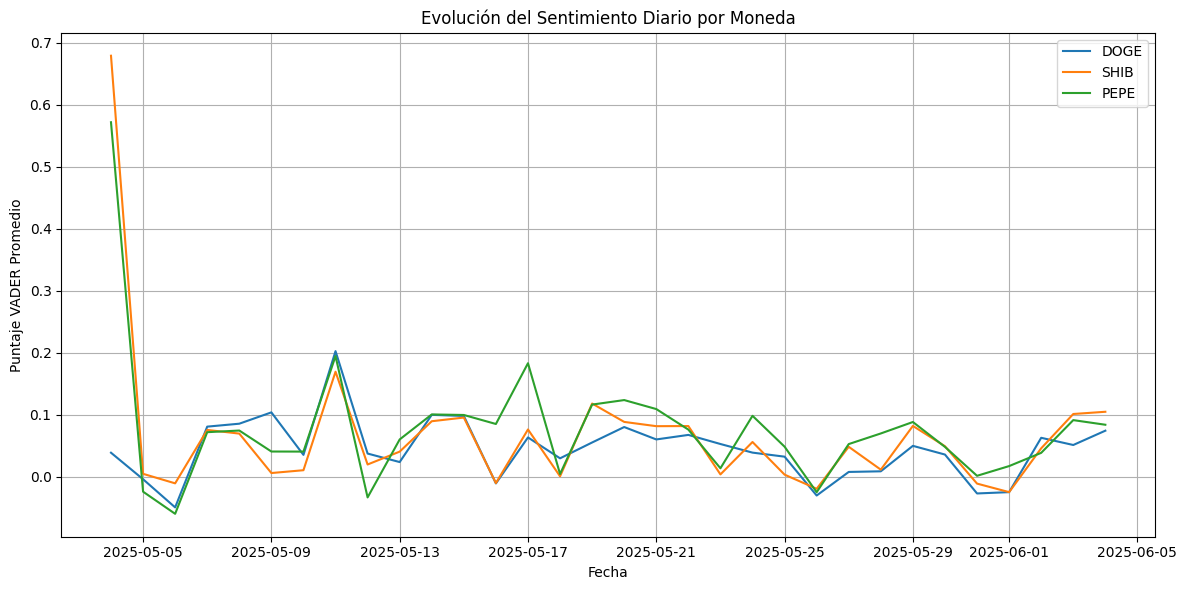

In [17]:
# Análisis básico
summary = df_news.groupby("coin")["score"].agg(["count", "mean", "std", "min", "max"]).reset_index()
print("Resumen por moneda:")
print(summary)

# Gráficos
for coin in df_news["coin"].unique():
    df_news[df_news["coin"] == coin]["score"].hist(bins=20, alpha=0.6)
    plt.title(f"Distribución de sentimiento para {coin}")
    plt.xlabel("Puntaje VADER")
    plt.ylabel("Número de Posts")
    plt.grid(True)
    plt.show()

# Gráfico de evolución temporal del sentimiento promedio diario
print("Evolución temporal del sentimiento (promedio diario por moneda):")
plt.figure(figsize=(12, 6))

for coin in df_news["coin"].unique():
    daily_avg = (
        df_news[df_news["coin"] == coin]
        .groupby(df_news["date"].dt.date)["score"]
        .mean()
    )
    plt.plot(daily_avg.index, daily_avg.values, label=coin.upper())

plt.title("Evolución del Sentimiento Diario por Moneda")
plt.xlabel("Fecha")
plt.ylabel("Puntaje VADER Promedio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 3.3 ChatGPT a través de la API de OpenAI

#4. Análisis, Visualización y Predicción de Volatilidad de las Memecoins con VADER (por tipo de coin)


## 4.1 VADER
En esta sección se analizará la relación entre volatilidad diaria y sentimiento social (VADER) para cada Memecoin individualmente: PEPE, DOGE y SHIBA INU.

El objetivo es identificar posibles diferencias o patrones particulares por cada coin.



In [18]:
# Load price data from MongoDB
def load_price_data(coin_name: str) -> pd.Series:

    cursor = collection_prices.find({
    "coin": {"$regex": coin_name, "$options": "i"}
})
    df = pd.DataFrame(list(cursor))

    if 'date' not in df.columns or 'price' not in df.columns:
        raise ValueError(f"Missing 'date' or 'price' column for coin: {coin_name}")

    if df['price'].dtype == object:
        df['price'] = df['price'].astype(str).str.replace(',', '.').astype(float)

    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date', 'price']).sort_values('date')
    df.set_index('date', inplace=True)
    df.index = df.index.normalize()

    return df['price']

In [19]:
# Load sentiment data from MongoDB
def load_sentiment_data(coin_name: str) -> pd.DataFrame:
    cursor = collection_sentiment.find({"coin": coin_name.upper()})
    df = pd.DataFrame(list(cursor))
    if df.empty:
        return pd.DataFrame()

    df['date'] = pd.to_datetime(df['date']).dt.normalize()
    return df

In [20]:
def forecast_volatility_lstm(coin_name: str, steps=5, sequence_length=10):
    # Extraer datos
    sentiment = pd.DataFrame(list(collection_sentiment.find({
        "$or": [
            {"coin": coin_name},
            {"coin": coin_name.upper()},
            {"coin": coin_name.lower()}
        ]
    })))
    print(f"Shape: {sentiment.shape}")
    print(f"Columns: {sentiment.columns.tolist()}")
    print(sentiment.head(3))
    if sentiment.empty or "date" not in sentiment.columns:
        raise ValueError(f"No se encontraron datos de sentimiento válidos para '{coin_name}' (vacío o sin columna 'date').")

    volatility = pd.DataFrame(list(collection_volatility.find({
    "coin": {"$regex": coin_name, "$options": "i"}
})))
    prices = pd.DataFrame(list(collection_prices.find({
    "coin": {"$regex": coin_name, "$options": "i"}
})))

    # VALIDACIÓN de datos vacíos o sin columna 'date'
    for name, df in [("sentiment", sentiment), ("volatility", volatility), ("prices", prices)]:
        if df.empty or "date" not in df.columns:
            raise ValueError(f"La colección de {name} para '{coin_name}' está vacía o no tiene columna 'date'.")

    # Normalizar fechas
    sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date
    volatility['date'] = pd.to_datetime(volatility['date']).dt.date
    prices['date'] = pd.to_datetime(prices['date']).dt.date

    # Agregar sentimiento diario
    sentiment_daily = sentiment.groupby('date')['score'].mean().reset_index()

    # Unir datasets
    df = pd.merge(volatility, prices, on="date", how="inner")
    df = pd.merge(df, sentiment_daily, on="date", how="left")
    df.fillna(0, inplace=True)
    df.sort_values("date", inplace=True)

    # Seleccionar features
    features = ['open', 'high', 'low', 'close', 'price', 'volume', 'market_cap', 'score']
    target = 'rel_volatility'

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(df[features + [target]])

    # Crear secuencias
    X, y = [], []
    for i in range(len(scaled) - sequence_length):
        X.append(scaled[i:i+sequence_length, :-1])
        y.append(scaled[i+sequence_length, -1])
    X, y = np.array(X), np.array(y)

    # Modelo LSTM
    model = Sequential()
    model.add(LSTM(64, activation='tanh', input_shape=(X.shape[1], X.shape[2])))
    model.add(Dense(1))
    model.compile(optimizer='adam', loss='mse')
    model.fit(X, y, epochs=20, batch_size=16, verbose=0, validation_split=0.1)

    # Predicción futura
    last_sequence = scaled[-sequence_length:, :-1]
    preds = []
    input_seq = last_sequence.copy()
    for _ in range(steps):
        pred = model.predict(np.expand_dims(input_seq, axis=0), verbose=0)[0][0]
        preds.append(pred)
        next_step = input_seq[-1]
        input_seq = np.append(input_seq[1:], [next_step], axis=0)

    return preds, df['rel_volatility'].values[-len(y):], y


In [21]:
def run_analysis(symbol: str, db_name: str):
    print(f"\nAnalyzing {symbol}...\n{'=' * 60}")

    # Cargar datos de sentimiento para visualización
    sentiment_df = load_sentiment_data(symbol)
    print(f"Fetched {len(sentiment_df)} sentiment posts.")

    # Predicción de volatilidad con LSTM
    preds, y_true, y_train = forecast_volatility_lstm(db_name)
    print("Predicción de volatilidad (escalada) para próximos días:")
    print(preds)

    # Gráfico: Volatilidad real vs predicha
    plt.figure(figsize=(12, 6))
    plt.title(f"{symbol} - Predicción de Volatilidad con LSTM")
    plt.plot(y_train, label="Volatilidad Real")
    plt.plot(range(len(y_train), len(y_train) + len(preds)), preds, label="Volatilidad Predicha", linestyle="--")
    plt.xlabel("Timestep")
    plt.ylabel("Volatilidad (escalada)")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

    # Si hay sentimiento, hacer correlación con volatilidad histórica
    if not sentiment_df.empty:
        sentiment_df['date'] = pd.to_datetime(sentiment_df['date']).dt.normalize()
        sentiment_daily = sentiment_df.groupby("date")["score"].mean()

        # Obtener precios para alinear con sentimiento
        price_series = load_price_data(db_name)
        price_series = price_series[~price_series.index.duplicated(keep='last')]

        # Intersección de fechas
        common_dates = price_series.index.intersection(sentiment_daily.index)
        if common_dates.empty:
            print("No overlapping dates between price and sentiment.")
            return

        aligned = pd.DataFrame({
            "Price": price_series.loc[common_dates],
            "Sentiment": sentiment_daily.loc[common_dates]
        })

        # Normalización para graficar
        aligned["Price_Norm"] = (aligned["Price"] - aligned["Price"].mean()) / aligned["Price"].std()
        aligned["Sentiment_Norm"] = (aligned["Sentiment"] - aligned["Sentiment"].mean()) / aligned["Sentiment"].std()

        plt.figure(figsize=(12, 5))
        plt.title(f"{symbol} - Precio vs Sentimiento (normalizado)")
        plt.plot(aligned.index, aligned["Price_Norm"], label="Precio (norm)", color="blue")
        plt.plot(aligned.index, aligned["Sentiment_Norm"], label="Sentimiento (norm)", color="orange")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()

        # Resumen por subreddit
        summary = sentiment_df.groupby(["subreddit", "filter"]).agg(
            count=("score", "count"),
            avg_sentiment=("score", "mean")
        ).sort_values("count", ascending=False).reset_index()

        from IPython.display import display
        print(f"\nResumen de sentimiento por subreddit para {symbol}:")
        display(summary)
    else:
        print("No sentiment data to plot or analyze.")



Analyzing DOGE...
Fetched 3550 sentiment posts.
Shape: (3550, 9)
Columns: ['_id', 'date', 'title', 'selftext', 'url', 'subreddit', 'coin', 'filter', 'score']
                        _id                date  \
0  68404f9d017519c748b62131 2025-05-12 13:55:37   
1  68404f9d017519c748b62137 2025-05-25 06:23:39   
2  68404f9d017519c748b6213a 2025-05-16 08:45:03   

                                title  \
0              Turning Doge into USDC   
1   A company that steals: Freewallet   
2  Looking for a dedicated hot wallet   

                                            selftext  \
0  Top of the morning everyone, I’m trying to tur...   
1  Hi everyone,\nPosting this today to bring visi...   
2  Was going to start this post detailing all the...   

                                                 url       subreddit  coin  \
0  https://reddit.com/r/CryptoCurrency/comments/1...  CryptoCurrency  DOGE   
1  https://reddit.com/r/CryptoCurrency/comments/1...  CryptoCurrency  DOGE   
2  https://r

/Users/sergio/anaconda3/envs/TFM/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Predicción de volatilidad (escalada) para próximos días:
[np.float32(0.15852381), np.float32(0.1592511), np.float32(0.16143337), np.float32(0.16143444), np.float32(0.16143441)]


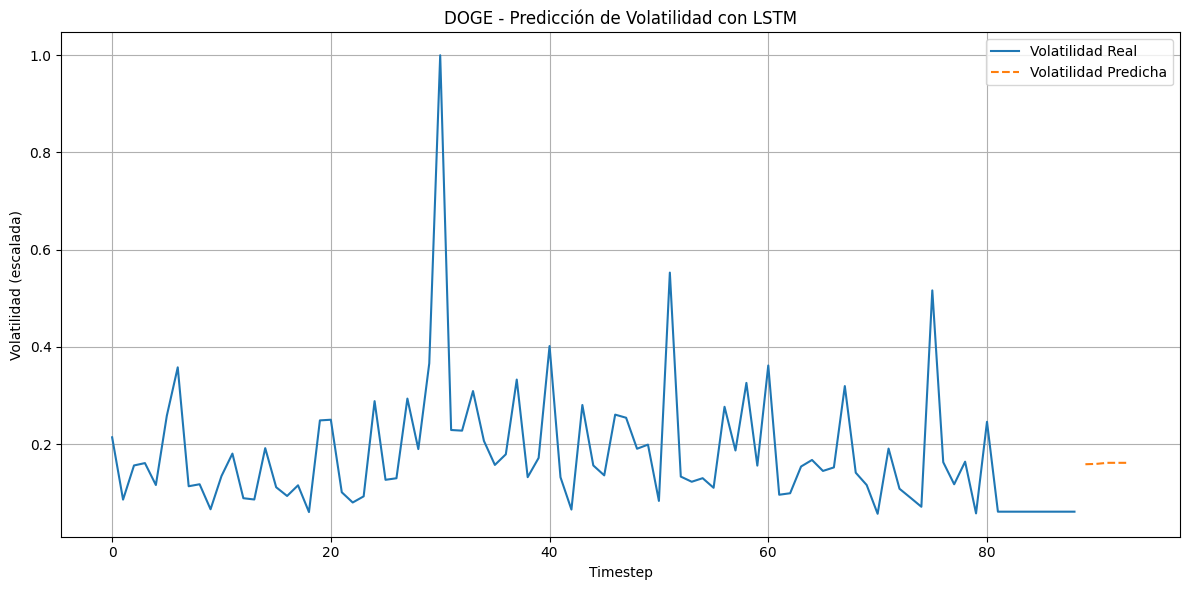

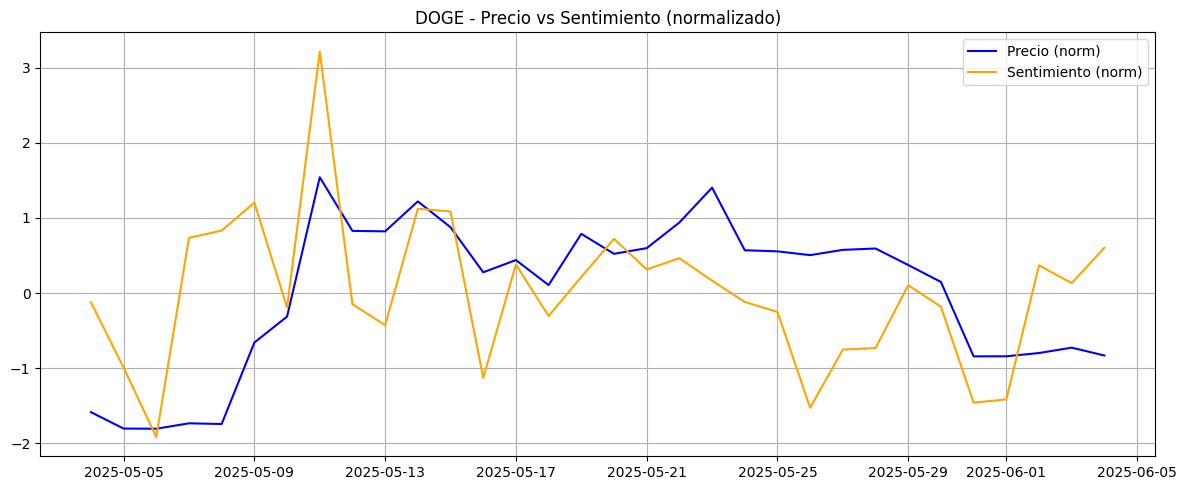


Resumen de sentimiento por subreddit para DOGE:


,subreddit,filter,count,avg_sentiment
0,Bitcoin,general,998,0.200263
1,worldnews,general,996,-0.144190
2,Economics,general,863,-0.060551
3,dogecoin,by_symbol,511,0.170293
4,ethereum,general,160,0.401904
5,CryptoCurrency,by_symbol,16,0.530100
6,altcoin,by_symbol,6,0.996033



Analyzing SHIB...
Fetched 3153 sentiment posts.
Shape: (3153, 9)
Columns: ['_id', 'date', 'title', 'selftext', 'url', 'subreddit', 'coin', 'filter', 'score']
                        _id                date  \
0  68404fd0017519c748b62f13 2025-05-19 14:54:41   
1  68404fd0017519c748b62f14 2025-05-10 11:34:21   
2  68404fd0017519c748b62f1b 2025-05-22 05:05:16   

                                    title  \
0      Kendu - The Chart Looks Incredible   
1  The KENDU comeback will blow your mind   
2                   SHIB Army let’s go!!!   

                                            selftext  \
0  Kendu started off as a memecoin, but is transi...   
1  Welcome to DeFi where a coin can only truly be...   
2  Every other coin is up 50, 75, 150% shib is up...   

                                                 url subreddit  coin  \
0  https://reddit.com/r/altcoin/comments/1kqayoe/...   altcoin  SHIB   
1  https://reddit.com/r/altcoin/comments/1kj6dq5/...   altcoin  SHIB   
2  https://red

/Users/sergio/anaconda3/envs/TFM/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Predicción de volatilidad (escalada) para próximos días:
[np.float32(0.16952297), np.float32(0.16832115), np.float32(0.1682423), np.float32(0.16825086), np.float32(0.16824876)]


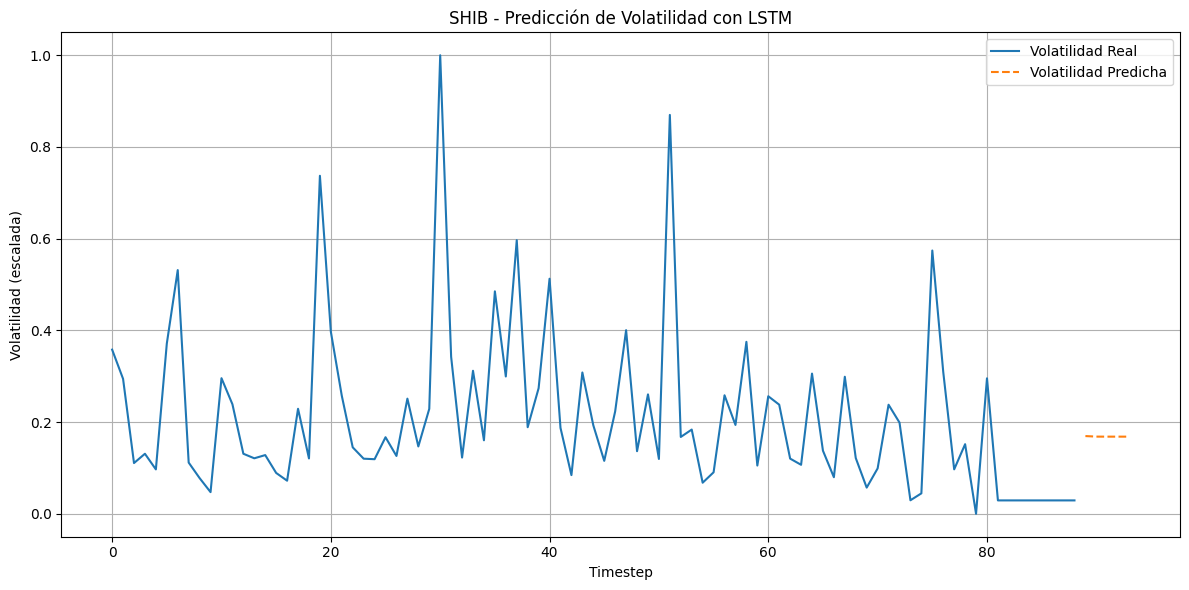

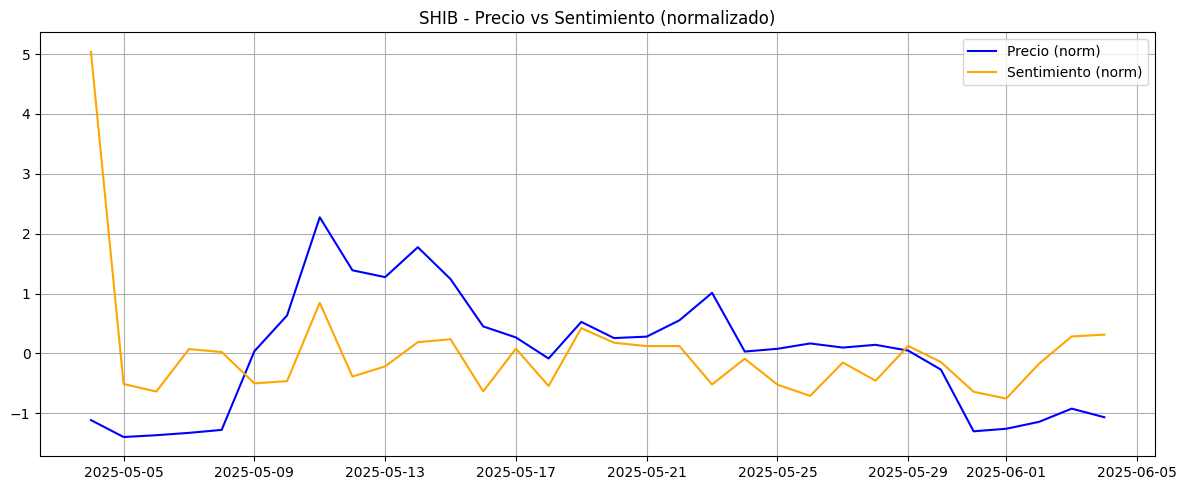


Resumen de sentimiento por subreddit para SHIB:


,subreddit,filter,count,avg_sentiment
0,Bitcoin,general,998,0.200263
1,worldnews,general,996,-0.144190
2,Economics,general,863,-0.060551
3,ethereum,general,160,0.401904
4,SHIBArmy,by_symbol,104,0.639460
5,shiba,by_symbol,18,0.432344
6,altcoin,by_symbol,12,0.666033
7,CryptoCurrency,by_symbol,2,0.968000



Analyzing PEPE...
Fetched 3307 sentiment posts.
Shape: (3307, 9)
Columns: ['_id', 'date', 'title', 'selftext', 'url', 'subreddit', 'coin', 'filter', 'score']
                        _id                date  \
0  68405006017519c748b63b5f 2025-05-17 14:14:34   
1  68405006017519c748b63b64 2025-05-13 14:31:09   
2  68405006017519c748b63b65 2025-05-31 18:10:56   

                                               title  \
0  I created a free, whiteboard-style interface f...   
1     An S&P 500 Company Featured Kendu In An Advert   
2                        Kendu: Check Out Our Murals   

                                            selftext  \
0  Most crypto trading bot platforms out there fa...   
1  As most of you have probably heard, Coinbase h...   
2  **What is Kendu**\n\nKendu is a memecoin(recen...   

                                                 url       subreddit  coin  \
0  https://reddit.com/r/CryptoCurrency/comments/1...  CryptoCurrency  PEPE   
1  https://reddit.com/r/altcoi

/Users/sergio/anaconda3/envs/TFM/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Predicción de volatilidad (escalada) para próximos días:
[np.float32(0.27795097), np.float32(0.27466246), np.float32(0.27421612), np.float32(0.27415806), np.float32(0.27414158)]


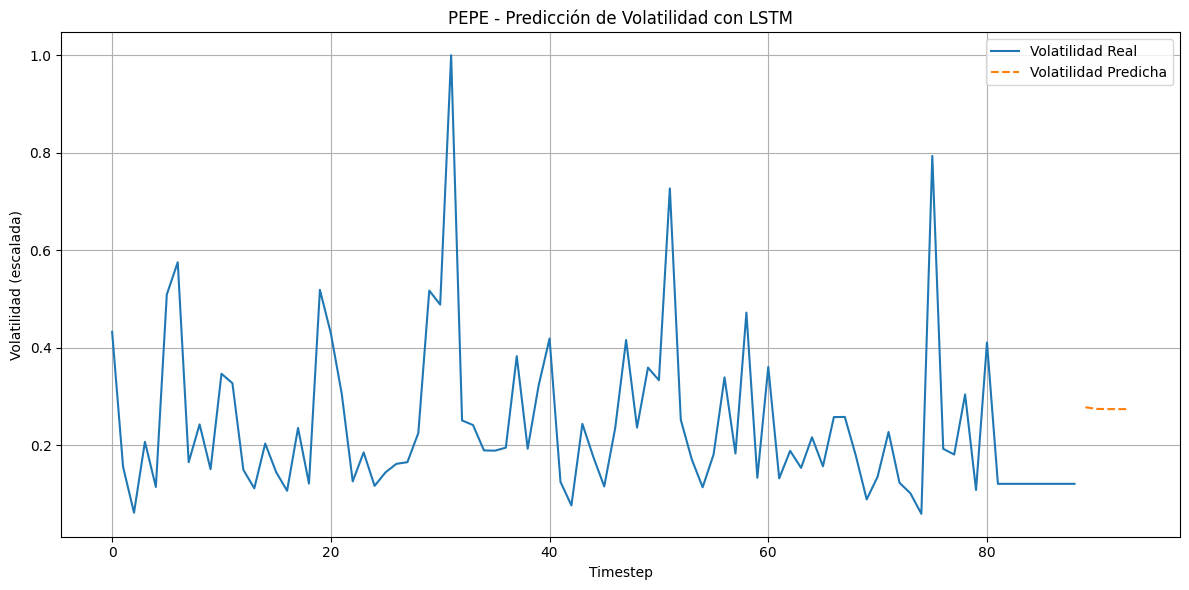

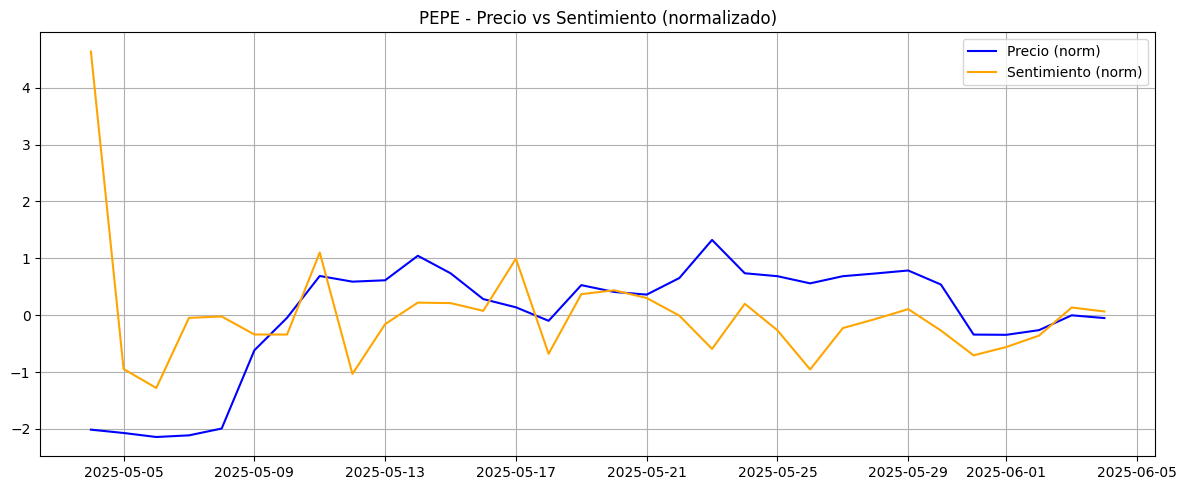


Resumen de sentimiento por subreddit para PEPE:


,subreddit,filter,count,avg_sentiment
0,Bitcoin,general,998,0.200263
1,worldnews,general,996,-0.144190
2,Economics,general,863,-0.060551
3,pepecoin,by_symbol,162,0.347451
4,ethereum,general,160,0.401904
5,cryptomoonshots,by_symbol,60,0.902460
6,PEPEthefrog,by_symbol,40,0.107655
7,altcoin,by_symbol,22,0.782955
8,CryptoCurrency,by_symbol,6,0.647667


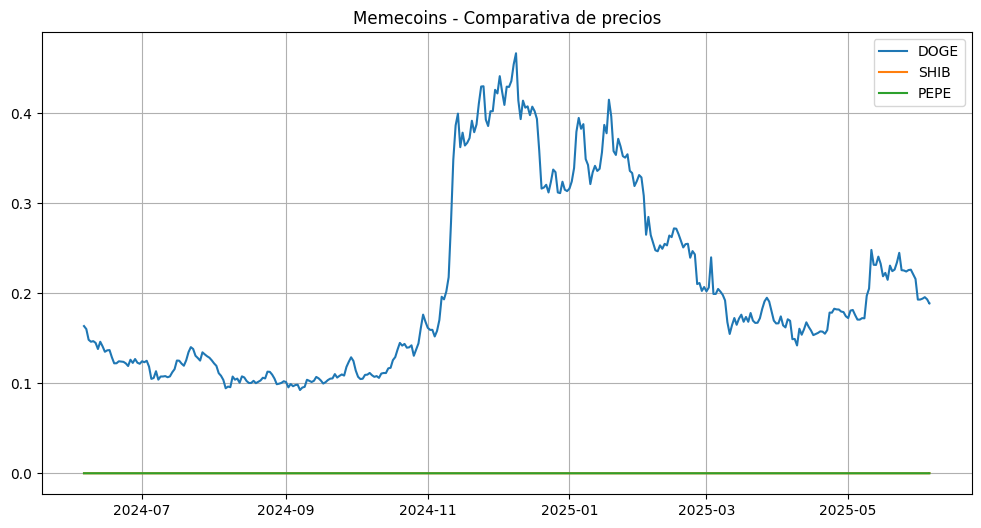

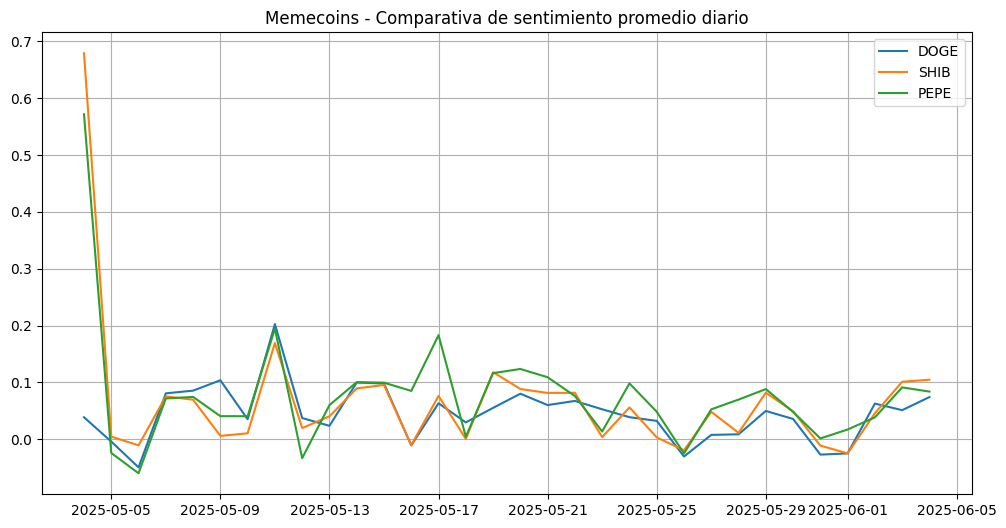

In [22]:
# Ejecutar análisis para todas las memecoins
memecoins = [
    {"symbol": "DOGE", "db_name": "doge"},
    {"symbol": "SHIB", "db_name": "shib"},
    {"symbol": "PEPE", "db_name": "pepe"}
]

for coin in memecoins:
    run_analysis(coin["symbol"], coin["db_name"])

# Comparación cruzada de precios
plt.figure(figsize=(12, 6))
plt.title("Memecoins - Comparativa de precios")

for coin in memecoins:
    price_series = load_price_data(coin["db_name"])
    plt.plot(price_series, label=coin["symbol"])

plt.legend()
plt.grid()
plt.show()

# Comparación cruzada de sentimiento
plt.figure(figsize=(12, 6))
plt.title("Memecoins - Comparativa de sentimiento promedio diario")

for coin in memecoins:
    sentiment_df = load_sentiment_data(coin["symbol"])
    if not sentiment_df.empty:
        daily_sentiment = sentiment_df.groupby("date")["score"].mean()
        plt.plot(daily_sentiment, label=coin["symbol"])

plt.legend()
plt.grid()
plt.show()

## 📊 Conclusiones por Moneda

### 🐶 DOGE

- Correlación parcial entre sentimiento y precio. En algunos tramos, ambos se alinean, aunque con cierto desfase temporal.  
- El sentimiento presenta alta volatilidad, con cambios bruscos.  
- La proyección de precio muestra estabilidad a corto plazo.  
- **Conclusión**: El sentimiento parece reaccionar fuertemente a eventos, pero no sostiene una dirección clara en el precio. Se espera lateralidad.

---

### 🐕 SHIB

- Al inicio, el sentimiento es muy alto y luego cae fuertemente, antes de que el precio responda.  
- Existe una ligera correlación inversa en ciertos tramos intermedios.  
- El modelo predice una evolución plana del precio.  
- **Conclusión**: La emoción inicial se disipa rápidamente, lo que podría indicar movimientos especulativos. No se esperan grandes cambios inmediatos.

---

### 🐸 PEPE

- Muestra una alineación más coherente entre sentimiento y precio que las otras monedas.  
- Aunque el sentimiento también es volátil, la trayectoria del precio tiende a seguir sus altibajos.  
- El forecast sugiere neutralidad de mercado.  
- **Conclusión**: PEPE es la más "estable" en términos de relación entre sentimiento y comportamiento de precio. No hay señales claras de ruptura.

---

## 📌 Conclusión General

- El modelo ARIMA predice estabilidad a corto plazo para las tres monedas.  
- El sentimiento no tiene una correlación perfecta, pero puede ser un indicador adelantado parcial, especialmente en el caso de PEPE.  
- Es importante combinar esta información con otros factores técnicos o fundamentales para tomar decisiones más informadas.

## 4.2 GPT

En esta sección se analizará la relación entre volatilidad diaria y sentimiento social (GPT) para cada Memecoin individualmente: PEPE, DOGE y SHIBA INU.

El objetivo es identificar posibles diferencias o patrones particulares por cada coin.